# Spotify Music Recommendation System
## Notebook 02 — Exploratory Data Analysis

**Purpose:** Understand the shape, distribution, and relationships in the data using simple, readable charts — one question per section.

## Table of Contents
1. [Setup & Imports](#1-setup--imports)
2. [Load Data](#2-load-data)
3. [Audio Feature Distributions](#3-audio-feature-distributions)
4. [Popularity Distribution](#4-popularity-distribution)
5. [Track Duration](#5-track-duration)
6. [Temporal Coverage](#6-temporal-coverage)
7. [Categorical Features](#7-categorical-features)
8. [Feature Correlations](#8-feature-correlations)
9. [How Features Changed Over Time](#9-how-features-changed-over-time)
10. [Genre Distribution (after fixing [] issue)](#10-genre-distribution)
11. [Top Artists](#11-top-artists)
12. [Key Findings](#12-key-findings)

## 1. Setup & Imports

In [57]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path('..').resolve()))

from src.data.load import load_data, load_data_genre, load_year
from src.data.preprocess import parse_genres, parse_artists

DATA_DIR    = Path('../data/raw')
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Figures will be saved to:', FIGURES_DIR.resolve())

Figures will be saved to: C:\Users\Victus\Music\Datascience\Projects\Recommendation_system\spotify_recommendation\reports\figures


## 2. Load Data

In [58]:
data       = load_data()        # from src.data.load
data_genre = load_data_genre()  # from src.data.load
year_df    = load_year()        # from src.data.load

print(f'Main dataset : {data.shape[0]:,} tracks, {data.shape[1]} columns')
print(f'Year range   : {data["year"].min()} – {data["year"].max()}')
data.head(3)

Main dataset : 170,653 tracks, 19 columns
Year range   : 1921 – 2020


,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339


## 3. Audio Feature Distributions

All 7 features below are on a 0–1 scale. We look at their histogram shapes to understand how the 170,653 tracks are spread across each dimension.

**Skewed right (most tracks near 0):** `instrumentalness`, `speechiness`, `liveness`  
 
**Bell-shaped (concentrated around the center):** `valence`, `danceability`, `energy`

**Uniformly distributed (spread across full range):** `acousticness`

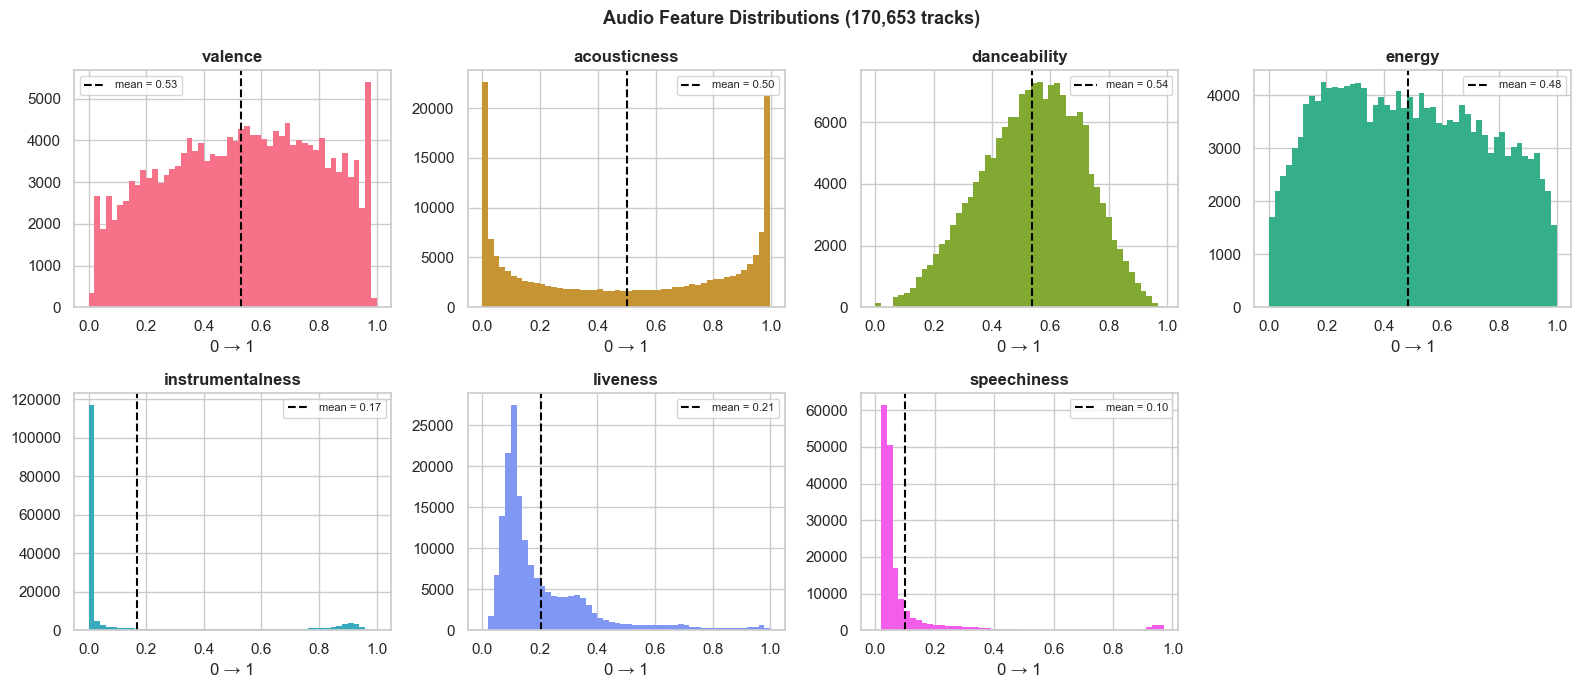

Skewness of each feature (higher = more right-skewed):
speechiness         4.05
liveness            2.15
instrumentalness    1.63
energy              0.11
acousticness       -0.03
valence            -0.11
danceability       -0.22


In [59]:
AUDIO = ['valence', 'acousticness', 'danceability', 'energy',
         'instrumentalness', 'liveness', 'speechiness']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colors = sns.color_palette('husl', 7)

for i, feat in enumerate(AUDIO):
    axes[i].hist(data[feat], bins=50, color=colors[i], edgecolor='none')
    axes[i].axvline(data[feat].mean(), color='black', linewidth=1.5, linestyle='--',
                    label=f'mean = {data[feat].mean():.2f}')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('0 → 1')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Audio Feature Distributions (170,653 tracks)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_audio_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Skewness of each feature (higher = more right-skewed):')
print(data[AUDIO].skew().sort_values(ascending=False).round(2).to_string())

## 4. Popularity Distribution

Spotify popularity is a score from 0 to 100 based on how often a track has been played recently. There is a large spike at 0 — these are mostly very old or obscure tracks that nobody plays anymore.

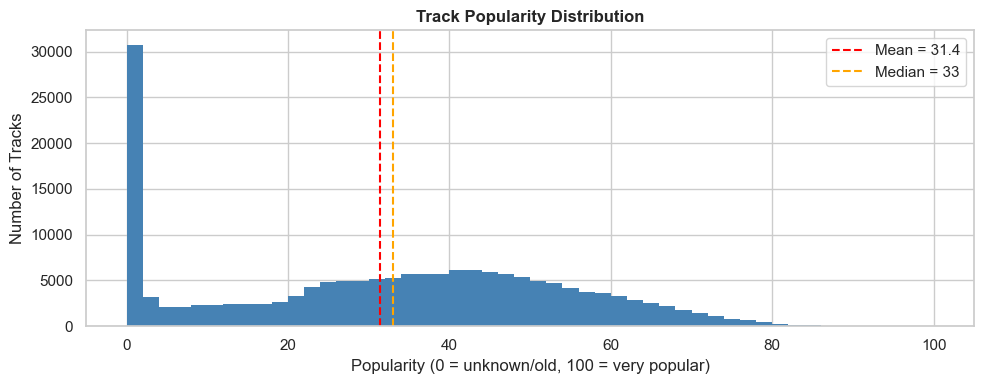

Tracks with popularity = 0 : 27,892 (16.3%)
These are typically old or very obscure recordings.


In [60]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(data['popularity'], bins=50, color='steelblue', edgecolor='none')
ax.axvline(data['popularity'].mean(),   color='red',    linewidth=1.5, linestyle='--',
           label=f'Mean = {data["popularity"].mean():.1f}')
ax.axvline(data['popularity'].median(), color='orange', linewidth=1.5, linestyle='--',
           label=f'Median = {data["popularity"].median():.0f}')
ax.set_title('Track Popularity Distribution', fontweight='bold')
ax.set_xlabel('Popularity (0 = unknown/old, 100 = very popular)')
ax.set_ylabel('Number of Tracks')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_popularity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

zero_pop = (data['popularity'] == 0).sum()
print(f'Tracks with popularity = 0 : {zero_pop:,} ({zero_pop/len(data)*100:.1f}%)')
print(f'These are typically old or very obscure recordings.')

## 5. Track Duration

Most songs are 2–5 minutes long. A small number of classical/ambient pieces run much longer.

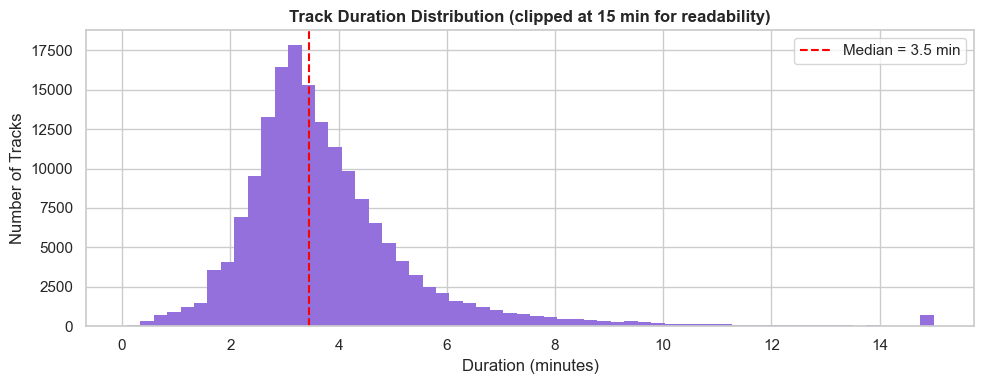

Median duration : 3.46 min
Tracks < 1 min  : 1,615  (interludes / intros — will filter)
Tracks > 10 min : 2,265  (classical / ambient pieces)


In [61]:
data['duration_min'] = data['duration_ms'] / 60_000

fig, ax = plt.subplots(figsize=(10, 4))
# Clip to 15 min so the chart is readable
ax.hist(data['duration_min'].clip(upper=15), bins=60, color='mediumpurple', edgecolor='none')
ax.axvline(data['duration_min'].median(), color='red', linewidth=1.5, linestyle='--',
           label=f'Median = {data["duration_min"].median():.1f} min')
ax.set_title('Track Duration Distribution (clipped at 15 min for readability)', fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Tracks')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_track_duration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median duration : {data["duration_min"].median():.2f} min')
print(f'Tracks < 1 min  : {(data["duration_min"] < 1).sum():,}  (interludes / intros — will filter)')
print(f'Tracks > 10 min : {(data["duration_min"] > 10).sum():,}  (classical / ambient pieces)')

## 6. Temporal Coverage

The dataset spans 100 years (1921–2020). Most tracks are from post-1990 because digital music catalogues grew rapidly after streaming arrived.

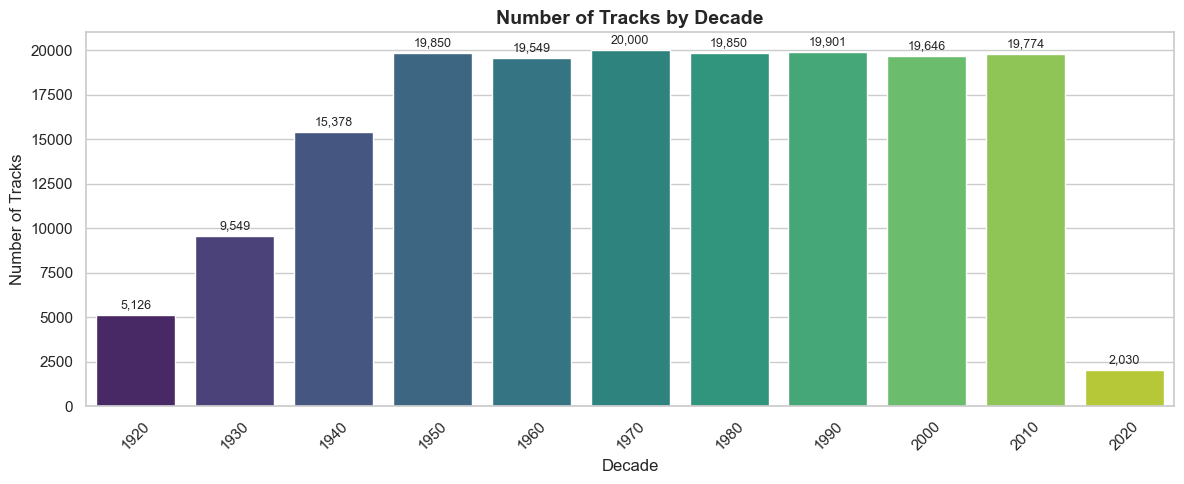

In [62]:
# decade must be computed before it is used
decade = (data['year'] // 10 * 10)

# Create decade column
plot_df = pd.DataFrame({
    'Decade': decade.astype(str)
})

# Get counts
counts = plot_df['Decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))

# Plot
sns.countplot(
    data=plot_df,
    x='Decade',
    order=counts.index,
    palette='viridis',
    ax=ax
)

# Add value labels
for p, count in zip(ax.patches, counts.values):
    ax.annotate(
        f'{count:,}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points'
    )

ax.set_title('Number of Tracks by Decade', fontsize=14, weight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Number of Tracks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_tracks_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Categorical Features

Three categorical features: `explicit` (does the track have explicit lyrics), `mode` (major or minor key), and `key` (which of 12 musical keys).

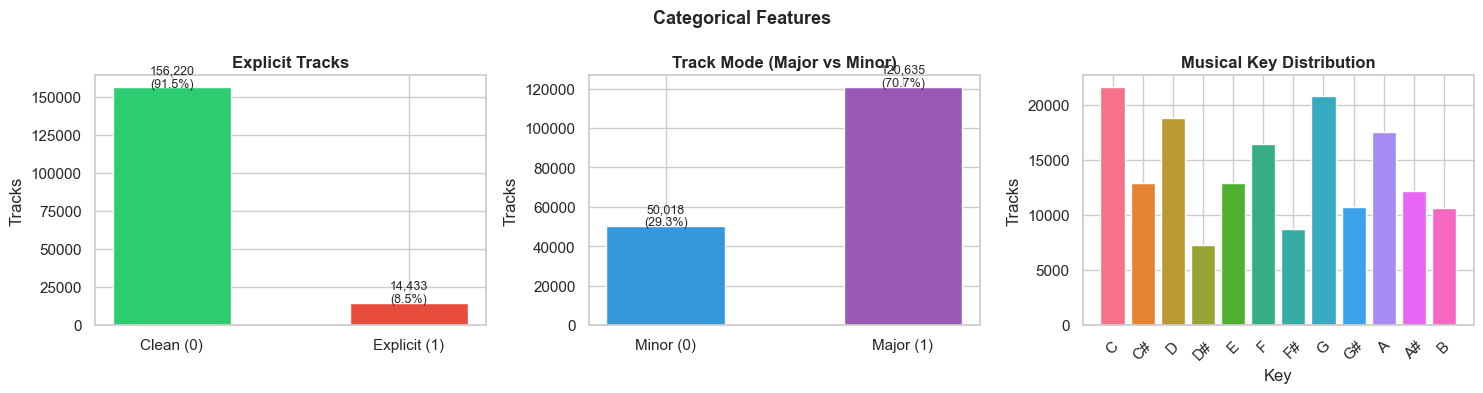

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Explicit
ec = data['explicit'].value_counts().sort_index()
axes[0].bar(['Clean (0)', 'Explicit (1)'], ec.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Explicit Tracks', fontweight='bold')
axes[0].set_ylabel('Tracks')
for i, v in enumerate(ec.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(data)*100:.1f}%)', ha='center', fontsize=9)

# Mode
mc = data['mode'].value_counts().sort_index()
axes[1].bar(['Minor (0)', 'Major (1)'], mc.values, color=['#3498db', '#9b59b6'], width=0.5)
axes[1].set_title('Track Mode (Major vs Minor)', fontweight='bold')
axes[1].set_ylabel('Tracks')
for i, v in enumerate(mc.values):
    axes[1].text(i, v + 500, f'{v:,}\n({v/len(data)*100:.1f}%)', ha='center', fontsize=9)

# Key
key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
kc = data['key'].value_counts().sort_index()
axes[2].bar(key_labels, kc.values, color=sns.color_palette('husl', 12))
axes[2].set_title('Musical Key Distribution', fontweight='bold')
axes[2].set_xlabel('Key')
axes[2].set_ylabel('Tracks')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Correlations

This heatmap shows how audio features relate to each other. Strong relationships:
- **Energy ↔ Loudness**: +0.76 (louder = more energetic)
- **Acousticness ↔ Energy**: −0.72 (acoustic tracks tend to be quiet and calm)
- **Popularity** has only weak links to audio features — sound alone does not predict popularity.

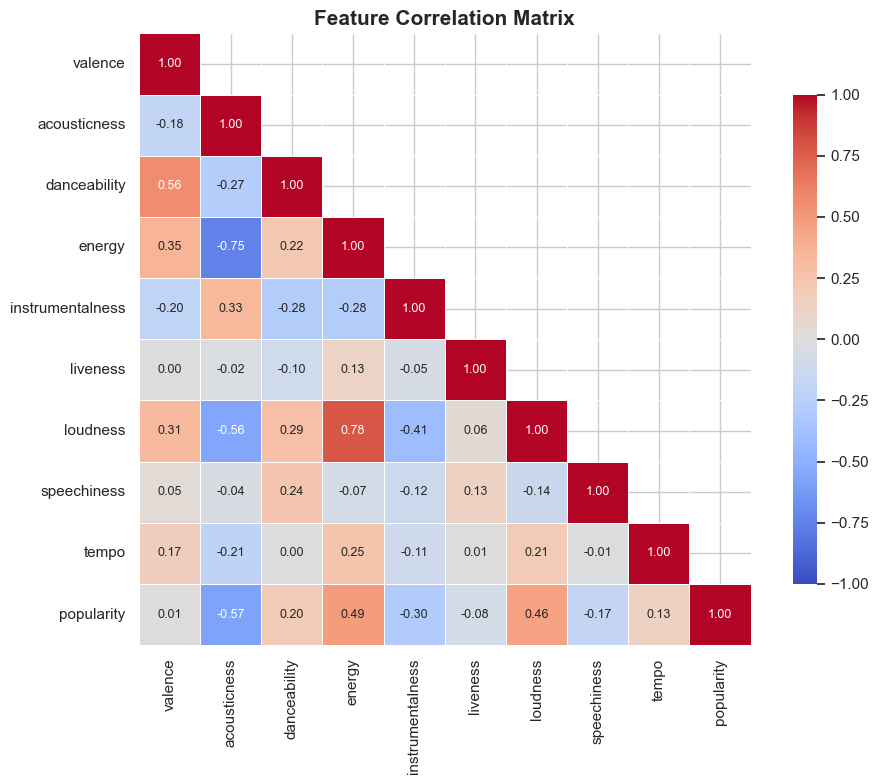

In [64]:
NUM_COLS = ['valence', 'acousticness', 'danceability', 'energy',
            'instrumentalness', 'liveness', 'loudness', 'speechiness',
            'tempo', 'popularity']

corr = data[NUM_COLS].corr()

# mask hides the upper triangle so each pair is shown only once
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1,
    center=0, annot=True, fmt='.2f', square=True,
    linewidths=0.5, linecolor='white', annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. How Features Changed Over Time

Using `data_by_year.csv` (mean values per year, 1921–2020).

Key trends:
- **Acousticness** has fallen steadily since the 1960s as electric recording took over
- **Energy, Danceability and Loudness** have increased
- **Valence** has slowly decreased over the decades

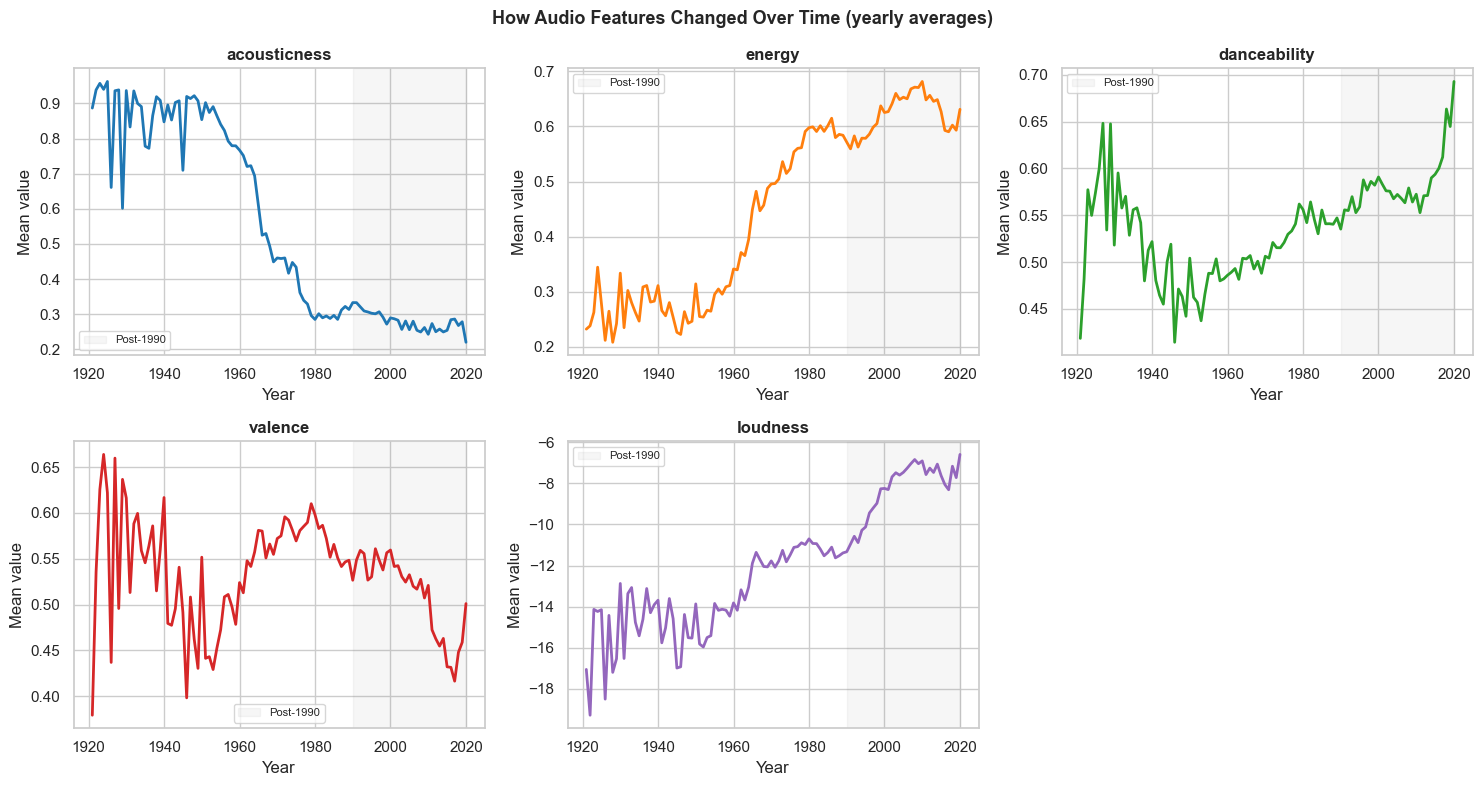

In [65]:
# Drop constant mode column before plotting
TREND_FEATS = ['acousticness', 'energy', 'danceability', 'valence', 'loudness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = sns.color_palette('tab10', len(TREND_FEATS))

for i, feat in enumerate(TREND_FEATS):
    axes[i].plot(year_df['year'], year_df[feat], color=colors[i], linewidth=2)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Mean value')
    axes[i].axvspan(1990, 2020, alpha=0.07, color='gray', label='Post-1990')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('How Audio Features Changed Over Time (yearly averages)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_features_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Genre Distribution

> **Important:** The `genres` column in `data_w_genres.csv` stores values as Python list strings. Many rows contain `'[]'` which looks non-null but means **no genre**. We must filter these out before any genre analysis.

- 9,857 artists (34.3%) have `genres = '[]'` — empty, not a real genre
- Only the remaining 18,823 artists have actual genre information

Rows with genres = []  : 9,857  ← hidden empty values
Rows with real genres  : 18,823



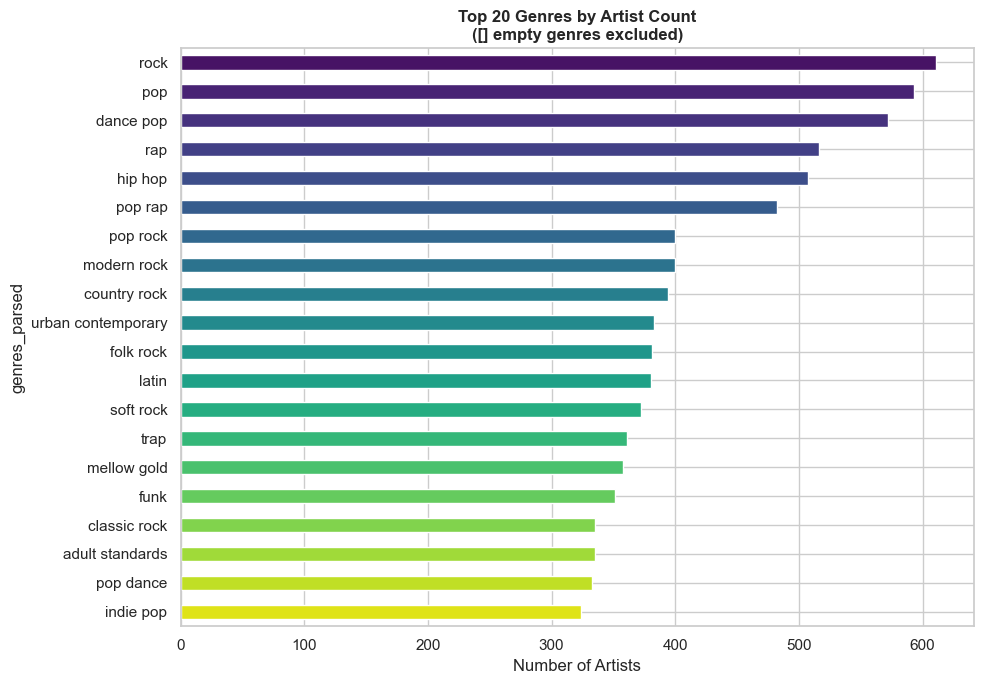

Total unique genre tags: 2972


In [66]:
# parse_genres() imported from src.data.preprocess — handles '[]' correctly
data_genre['genres_parsed'] = data_genre['genres'].apply(parse_genres)

empty_genre_count = data_genre['genres_parsed'].apply(len).eq(0).sum()
print(f'Rows with genres = []  : {empty_genre_count:,}  ← hidden empty values')
print(f'Rows with real genres  : {len(data_genre) - empty_genre_count:,}')
print()

genre_series = data_genre['genres_parsed'].explode()
genre_series = genre_series[genre_series.str.strip() != '']
top_genres = genre_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_genres.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(top_genres)))
ax.invert_yaxis()
ax.set_title('Top 20 Genres by Artist Count\n([] empty genres excluded)', fontweight='bold')
ax.set_xlabel('Number of Artists')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '08_genre_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total unique genre tags: {genre_series.nunique()}')

## 11. Top Artists

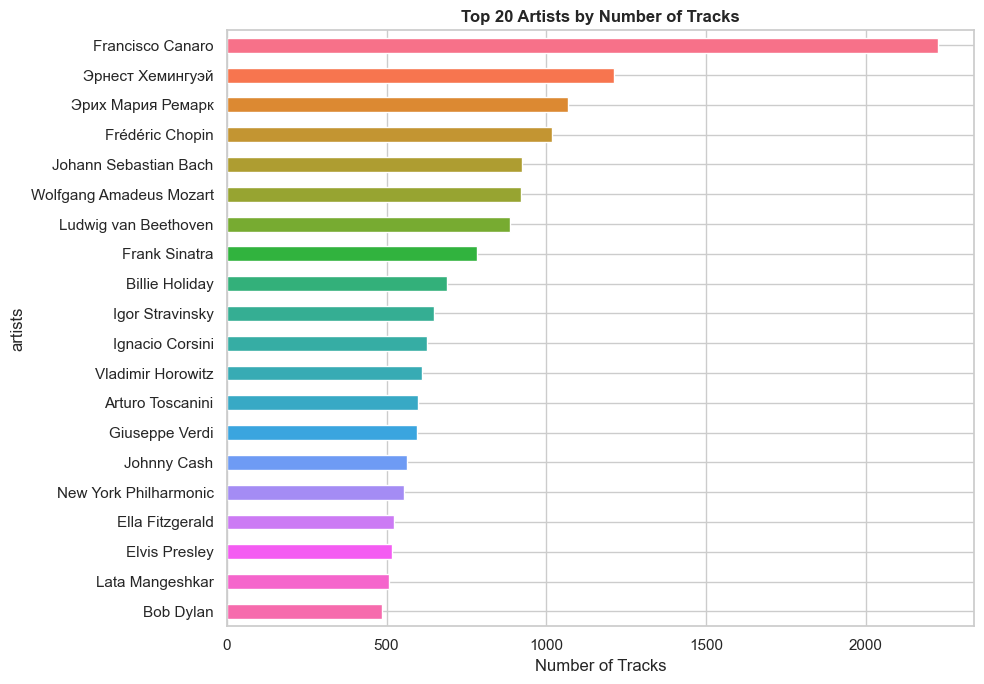

In [67]:
# parse_artists() imported from src.data.preprocess — handles list strings correctly
all_artists = data['artists'].apply(parse_artists).explode()
top_artists = all_artists.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_artists.plot(kind='barh', ax=ax, color=sns.color_palette('husl', len(top_artists)))
ax.invert_yaxis()
ax.set_title('Top 20 Artists by Number of Tracks', fontweight='bold')
ax.set_xlabel('Number of Tracks')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_top_artists.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Key Findings

These findings directly guide how we clean and use the data:

| Finding | What to do |
|---|---|
| `instrumentalness`, `speechiness`, `liveness` are right-skewed | Apply log transform before modelling |
| 34% of `genres` values are hidden-empty `[]` | Filter `[]` before any genre analysis or join |
| `artists` in `data.csv` are list strings | Parse with `ast.literal_eval()` in preprocessing |
| `popularity = 0` for 15%+ of tracks | Flag these — they are obscure, not missing |
| `mode` in `data_by_year` is always 1 | Drop this column |
| `release_date` has mixed formats | Use `year` column instead |
| Tracks < 1 min exist (interludes) | Filter out in cleaning |
| Energy ↔ Loudness strongly correlated (+0.76) | Consider this when building feature vectors |

**Next:** `03_data_cleaning_and_preprocessing.ipynb` — Clean and preprocess the data for modelling.